## Notebook to generate a suite of tests to verify the quality of generation of the trained model

In [1]:
import glob
import json
import tiktoken # for token counting
import numpy as np
from collections import defaultdict
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
from datetime import datetime
import pandas as pd
import os
client = OpenAI(api_key = os.getenv('OPENAI_API_KEY'))

In [2]:
PROMPT_PART_1 = \
f"""Generate the structure of a school activity to help students learn.
The activity must contain a layout structure where texts, images, tables or any other element that can help students' learning are positioned. 
These elements must be arranged in such a way that they are consistent with the proposed question. For example: if the question asks the student to link images, the images must be separated in such a way that it is possible for the student to link them.
The structure of the activity must be specified using the HTML language, and the CSS language to position text, images, tables, or any element present in the activity.
If the activity contains images, add a description of the image in the “alt” attribute. This description must be consistent with the activity specification and provide all the information necessary for the student to be able to answer the activity.
Also add an explanation for the elements used in the activity, in a new “exp” attribute. This attribute must be specified within the HTML tags and will explain the purpose of that structure in the activity. 
When it is necessary to use CSS, add an explanation in the form of comments above the class. This CSS is used to organize the layout of the activity so that it is creative and fun for the student.
Generate a textual description of the activity. This description must be specified in JSON format and must contain the following attributes:

task: the objective of the question, what the student will learn by answering.
layout: a detailed description of how each html elements are organized in the layout of the question, explain where the elements are placed.
answer: what the student will have to do to correctly answer that activity, add the answer and all the infos needed to answer the question

Generate the JSON description, and then generate the HTML structure containing the layout.
Do not generate iteractive HTML, this activitie is intended to be resolved with a pen and paper.
Be careful that the size of the images does not exceed the size of the activity

To generate a new activity use the following parameters:

"""

PROMPT_PART_2 = \
"""
Where:

level: is the school year is that activity intended for.
subject: is the school subject that activity is designed for.
theme: is the topic that activity wants to work on.
sheet width: is the desired width of the activity sheet.
task: is what the student must do to answer the activity.

Stick to the following rules:

Don't add anything outside the textual description and the HMTL of the activity.
Generate an activity that is creative and helps the student learn in a playful way, using the parameters specified above.
"""

In [3]:
def make_request_gpt(prompt, theme, layout, model, temperature = 1):
    
    para = \
f"""level: 2nd year of fundamental,
subject: addition,
theme: {theme},
sheet width: 800px,
layout: {layout}"""
    
    prompt = prompt.replace("<parameters>",para)
    
    completion = client.chat.completions.create(
		model=model,
		temperature= temperature,
		messages=[
			{"role": "system", "content": "You are an assistant who helps a teacher create activities to help students learn"},
			{"role": "user", "content": prompt}
		]	
	)

    output = completion.choices[0].message.to_dict()['content']
    
    return output

In [8]:
PROMPT = \
f"""
{PROMPT_PART_1}

<parameters>

{PROMPT_PART_2}
"""

themes = ["cafeteria","music", "desert", "circus", "dinosaurs" ]#,, "desert"]
# layouts = ["observe image, write answer","observe images, write answer","observe images, draw answer","observe images, link items"]
layouts = ["observe image, write answer","observe images, write answer", "observe images, draw answer","observe images, link items"]
AMOUNT_POPLE = 1

In [10]:
file_to_save_predictions = str(datetime.now()) + ".txt"
MODEL = "ft:gpt-3.5-turbo-0125:ufcg::9YN9J0K7"
TEMPERATURE = 0.5
dir_save = "runs/experiment-6-8-06-2025"

count = 1
lines = []
for _ in range(AMOUNT_POPLE):
	for theme in themes:
		for layout in layouts:
			output = make_request_gpt(PROMPT, theme, layout, MODEL, TEMPERATURE)

			filename = f"{count}.html"
			with open(f"{dir_save}/htmls/{filename}","w",encoding='utf-8') as file:
				file.write(output)

			lines.append([filename, theme, layout ]) #,'','','','','',''])
			count += 1
			print(count)
    
df = pd.DataFrame(lines,columns=['Filename', 'Theme', 'Layout'])# 'Answerable','Naturalness','Usefulness','Diversity and Controllability','Personalization','Explainability'])
if not os.path.exists(dir_save):
    os.makedirs(dir_save)
df.to_csv(f"{dir_save}/questions.csv",index=False)

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


## analyzing the data after giving the scores

In [32]:
data = pd.read_csv(f"{dir_save}/questions.csv")
data = data.rename(columns={"layout_ok": "layout", "explanations_ok": "explanations", "contextualiztion": "contextualization", "image_descriptions": "image descriptions"})

In [33]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.set_theme()

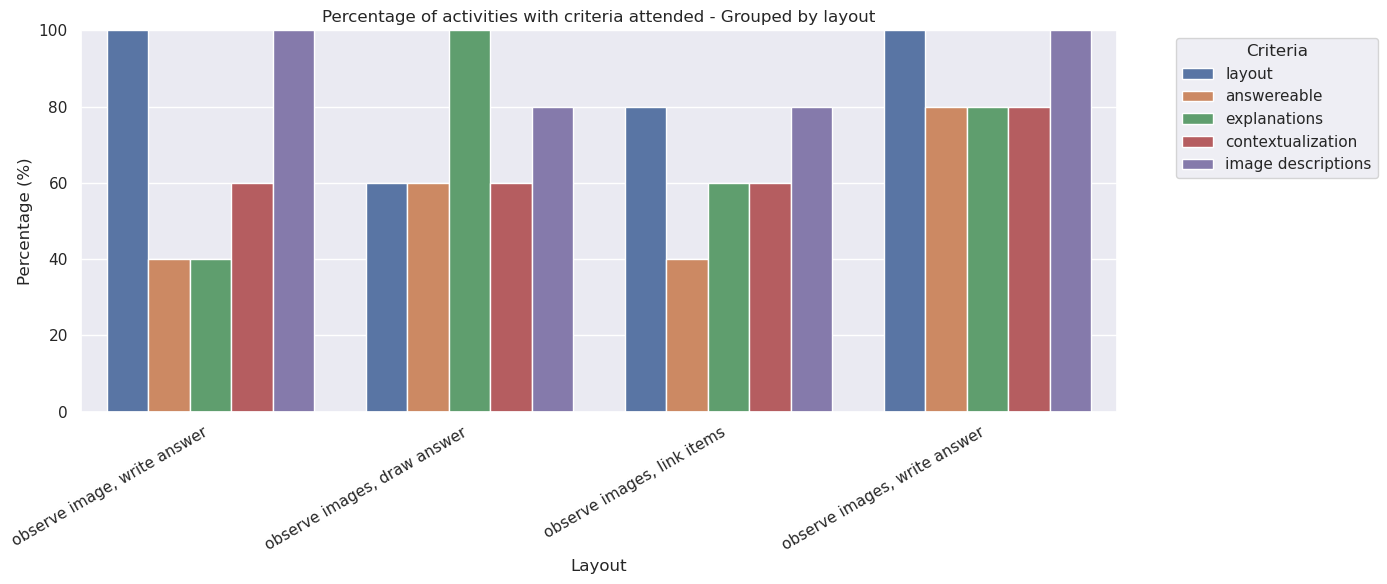

In [38]:
features = ['layout', 'answereable','explanations', 'contextualization', 'image descriptions']

# Calcular total de arquivos por layout}
total_por_layout = df.groupby('Layout').size().rename('Total')

# Calcular contagem de 1 por feature e layout
contagem = data.groupby('Layout')[features].sum()

# Calcular porcentagem
porcentagem = contagem.div(total_por_layout, axis=0) * 100

# Reformular para formato longo
porcentagem_long = porcentagem.reset_index().melt(
    id_vars='Layout', var_name='Criteria', value_name='Porcentagem'
)

# Plotar com seaborn
plt.figure(figsize=(14, 6))
sns.barplot(data=porcentagem_long, x='Layout', y='Porcentagem', hue='Criteria')
plt.title('Percentage of activities with criteria attended - Grouped by layout')
plt.ylabel('Percentage (%)')
# plt.xlabel('Layout')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 100)
plt.legend(title='Criteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

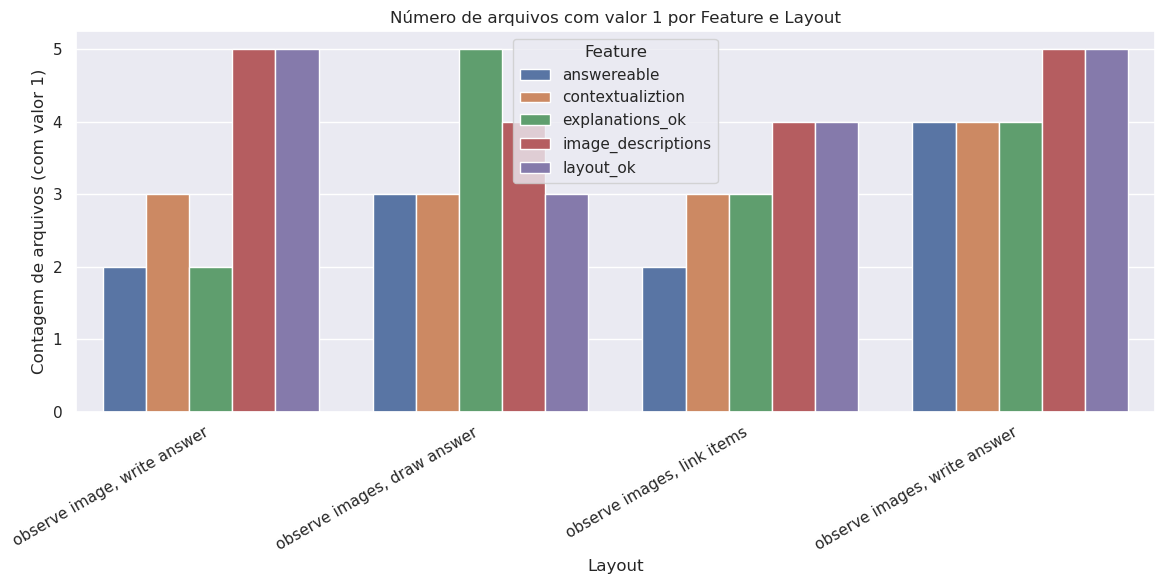

In [ ]:
melted = data.melt(id_vars=['Layout'], value_vars=['layout_ok', 'answereable','explanations_ok', 'contextualiztion', 'image_descriptions'],
                 var_name='Feature', value_name='Value')
grouped = (
    melted.groupby(['Layout', 'Feature'])['Value']
    .sum()
    .reset_index(name='Count')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='Layout', y='Count', hue='Feature')
plt.xticks(rotation=30, ha='right')
plt.title('Número de arquivos com valor 1 por Feature e Layout')
plt.ylabel('Contagem de arquivos (com valor 1)')
plt.tight_layout()
plt.show()